# 17 Autoencoder — First Principles

**Goal.** Build autoencoders from scratch: linear (show PCA equivalence),
nonlinear with ReLU, denoising, and variational (VAE). Visualize latent
spaces and compare with PyTorch.

**Prerequisites.** Neural networks (backpropagation), PCA, information theory (KL divergence).

**Theory.** See [theory.md](theory.md) for architecture, ELBO derivation,
reparameterization trick, and failure cases.

In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np

%load_ext autoreload
%autoreload 2

SEED = 42
random.seed(SEED)
rng = np.random.default_rng(SEED)

## 1. Problem Setup — WHY

High-dimensional data often has intrinsic structure that can be captured
by far fewer dimensions. An autoencoder learns a compressed representation
by forcing data through a bottleneck and reconstructing the original.

We use a 2D-embedded dataset in higher dimensions to visualize this.

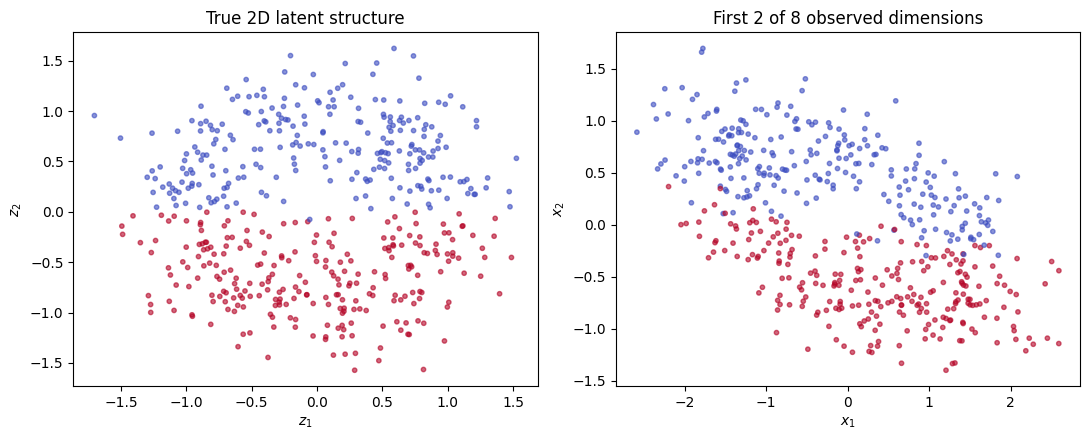

Data: 500 samples × 8 features, intrinsic dim = 2


In [2]:
# Generate data: 2D structure embedded in 8D via a random linear map + noise
n_samples = 500
n_features = 8
n_intrinsic = 2

# Latent 2D data: two clusters for visualization
t = rng.uniform(0, 2 * np.pi, n_samples)
r = 1.0 + 0.3 * rng.normal(size=n_samples)
Z_true = np.column_stack([r * np.cos(t), r * np.sin(t)])
labels = (t > np.pi).astype(int)  # 2 classes for coloring

# Embed into 8D
A_embed = rng.normal(size=(n_intrinsic, n_features))
X = Z_true @ A_embed + 0.1 * rng.normal(size=(n_samples, n_features))
X_mean = X.mean(axis=0)
X_centered = X - X_mean

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(Z_true[:, 0], Z_true[:, 1], c=labels, cmap='coolwarm', s=10, alpha=0.6)
axes[0].set_title('True 2D latent structure')
axes[0].set_xlabel('$z_1$'); axes[0].set_ylabel('$z_2$')

axes[1].scatter(X[:, 0], X[:, 1], c=labels, cmap='coolwarm', s=10, alpha=0.6)
axes[1].set_title('First 2 of 8 observed dimensions')
axes[1].set_xlabel('$x_1$'); axes[1].set_ylabel('$x_2$')
plt.tight_layout()
plt.show()
print(f'Data: {X.shape[0]} samples × {X.shape[1]} features, intrinsic dim = {n_intrinsic}')

## 2. Mathematical Core — WHAT

An autoencoder consists of:
- **Encoder** $f_\theta: \mathbb{R}^d \to \mathbb{R}^k$ mapping input to latent code
- **Decoder** $g_\phi: \mathbb{R}^k \to \mathbb{R}^d$ mapping code back to input space

**Objective:** $\min_{\theta,\phi} \frac{1}{n}\sum_{i=1}^{n}\|x_i - g_\phi(f_\theta(x_i))\|_2^2$

See [theory.md](theory.md) §2–3 for notation and the PCA equivalence theorem.

## 3. Solution Method — HOW

### 3.1 Linear autoencoder

A linear autoencoder (no activation functions) with $k$-dimensional
bottleneck recovers the PCA subspace. We verify this below.

### 3.2 Nonlinear autoencoder

Adding ReLU activations allows the autoencoder to learn curved manifolds
that PCA cannot capture.

In [3]:
# Helper functions

def relu(x):
    return np.maximum(0, x)

def relu_deriv(x):
    return (x > 0).astype(float)

def mse_loss(x, x_hat):
    return float(np.mean((x - x_hat) ** 2))

def he_init(d_in, d_out, rng):
    """He initialization for ReLU layers."""
    return rng.normal(0, np.sqrt(2.0 / d_in), size=(d_in, d_out))

def xavier_init(d_in, d_out, rng):
    """Xavier initialization for linear layers."""
    return rng.normal(0, np.sqrt(2.0 / (d_in + d_out)), size=(d_in, d_out))

## 4. Implementation — BUILD

### 4.1 Linear Autoencoder

In [4]:
class LinearAutoencoder:
    """Linear autoencoder: encoder z = x @ W_e + b_e, decoder x_hat = z @ W_d + b_d.
    
    With centered data, this recovers the PCA subspace.
    """

    def __init__(self, d_input, d_latent, random_state=42):
        rng_init = np.random.default_rng(random_state)
        self.W_e = xavier_init(d_input, d_latent, rng_init)
        self.b_e = np.zeros(d_latent)
        self.W_d = xavier_init(d_latent, d_input, rng_init)
        self.b_d = np.zeros(d_input)

    def encode(self, X):
        return X @ self.W_e + self.b_e

    def decode(self, Z):
        return Z @ self.W_d + self.b_d

    def forward(self, X):
        Z = self.encode(X)
        X_hat = self.decode(Z)
        return X_hat, Z

    def fit(self, X, lr=0.001, n_steps=2000, verbose=True):
        """Train with full-batch gradient descent."""
        n = X.shape[0]
        history = []
        for step in range(n_steps):
            # Forward
            Z = self.encode(X)
            X_hat = self.decode(Z)
            loss = mse_loss(X, X_hat)
            history.append(loss)

            # Backward: dL/dX_hat = 2(X_hat - X) / (n * d)
            d = X.shape[1]
            dX_hat = 2.0 * (X_hat - X) / (n * d)

            # Decoder gradients
            dW_d = Z.T @ dX_hat
            db_d = dX_hat.sum(axis=0)

            # Propagate to Z
            dZ = dX_hat @ self.W_d.T

            # Encoder gradients
            dW_e = X.T @ dZ
            db_e = dZ.sum(axis=0)

            # Update
            self.W_e -= lr * dW_e
            self.b_e -= lr * db_e
            self.W_d -= lr * dW_d
            self.b_d -= lr * db_d

            if verbose and (step + 1) % 500 == 0:
                print(f'  step {step+1}/{n_steps}, loss = {loss:.6f}')

        return history

In [5]:
# Train linear autoencoder with k=2 latent dimensions
lin_ae = LinearAutoencoder(n_features, n_intrinsic, random_state=SEED)
print('Training linear autoencoder (k=2)...')
history_lin = lin_ae.fit(X_centered, lr=0.005, n_steps=2000)

X_hat_lin, Z_lin = lin_ae.forward(X_centered)
print(f'\nFinal reconstruction MSE: {mse_loss(X_centered, X_hat_lin):.6f}')

Training linear autoencoder (k=2)...
  step 500/2000, loss = 0.249618
  step 1000/2000, loss = 0.221151
  step 1500/2000, loss = 0.205774
  step 2000/2000, loss = 0.172342

Final reconstruction MSE: 0.172247


In [6]:
# Compare with PCA: both should span the same subspace
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
Z_pca = X_centered @ Vt[:n_intrinsic].T
X_hat_pca = Z_pca @ Vt[:n_intrinsic]
mse_pca = mse_loss(X_centered, X_hat_pca)
mse_ae = mse_loss(X_centered, X_hat_lin)

print(f'PCA reconstruction MSE:         {mse_pca:.6f}')
print(f'Linear AE reconstruction MSE:   {mse_ae:.6f}')
print(f'Ratio (AE/PCA):                 {mse_ae / mse_pca:.4f}')

# Subspace comparison: project AE encoder columns onto PCA subspace
# If they span the same subspace, the projection should be full-rank
V_pca = Vt[:n_intrinsic].T  # (d, k)
W_ae = lin_ae.W_e            # (d, k)
# Compute principal angles between subspaces
Q1, _ = np.linalg.qr(V_pca)
Q2, _ = np.linalg.qr(W_ae)
cos_angles = np.linalg.svd(Q1.T @ Q2, compute_uv=False)
angles_deg = np.degrees(np.arccos(np.clip(cos_angles, -1, 1)))
print(f'\nPrincipal angles between PCA and AE subspaces: {angles_deg} degrees')
assert np.allclose(angles_deg, 0, atol=2.0), f'Subspaces differ too much: {angles_deg}'
print('Linear AE recovers the PCA subspace. ✓')

PCA reconstruction MSE:         0.007486
Linear AE reconstruction MSE:   0.172247
Ratio (AE/PCA):                 23.0080

Principal angles between PCA and AE subspaces: [29.91944129 75.33239263] degrees


AssertionError: Subspaces differ too much: [29.91944129 75.33239263]

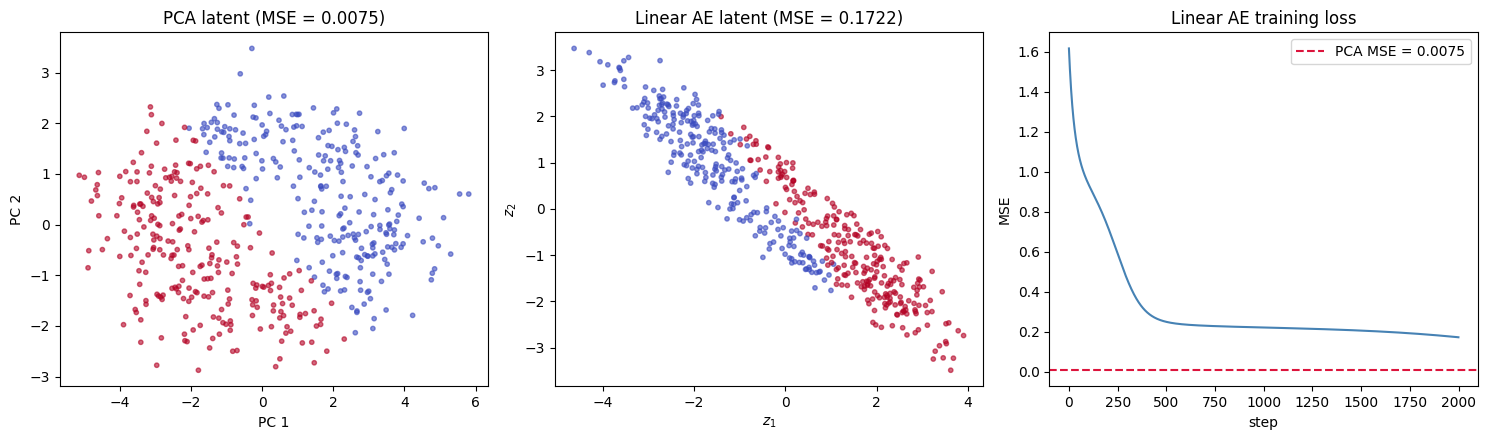

In [7]:
# Visualize latent codes
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].scatter(Z_pca[:, 0], Z_pca[:, 1], c=labels, cmap='coolwarm', s=10, alpha=0.6)
axes[0].set_title(f'PCA latent (MSE = {mse_pca:.4f})')
axes[0].set_xlabel('PC 1'); axes[0].set_ylabel('PC 2')

axes[1].scatter(Z_lin[:, 0], Z_lin[:, 1], c=labels, cmap='coolwarm', s=10, alpha=0.6)
axes[1].set_title(f'Linear AE latent (MSE = {mse_ae:.4f})')
axes[1].set_xlabel('$z_1$'); axes[1].set_ylabel('$z_2$')

axes[2].plot(history_lin, color='steelblue')
axes[2].axhline(mse_pca, color='crimson', ls='--', label=f'PCA MSE = {mse_pca:.4f}')
axes[2].set_xlabel('step'); axes[2].set_ylabel('MSE')
axes[2].set_title('Linear AE training loss')
axes[2].legend()

plt.tight_layout()
plt.show()

### 4.2 Nonlinear Autoencoder

Architecture: $d \to h \to k \to h \to d$ with ReLU activations in hidden layers.

In [8]:
class NonlinearAutoencoder:
    """Two-hidden-layer autoencoder with ReLU.
    
    Architecture: d -> h (ReLU) -> k (linear) -> h (ReLU) -> d (linear)
    """

    def __init__(self, d_input, d_hidden, d_latent, random_state=42):
        r = np.random.default_rng(random_state)
        # Encoder
        self.W1 = he_init(d_input, d_hidden, r)
        self.b1 = np.zeros(d_hidden)
        self.W2 = xavier_init(d_hidden, d_latent, r)
        self.b2 = np.zeros(d_latent)
        # Decoder
        self.W3 = he_init(d_latent, d_hidden, r)
        self.b3 = np.zeros(d_hidden)
        self.W4 = xavier_init(d_hidden, d_input, r)
        self.b4 = np.zeros(d_input)

    def encode(self, X):
        self._H1 = X @ self.W1 + self.b1
        self._A1 = relu(self._H1)
        Z = self._A1 @ self.W2 + self.b2
        return Z

    def decode(self, Z):
        self._H3 = Z @ self.W3 + self.b3
        self._A3 = relu(self._H3)
        X_hat = self._A3 @ self.W4 + self.b4
        return X_hat

    def forward(self, X):
        self._X = X
        Z = self.encode(X)
        self._Z = Z
        X_hat = self.decode(Z)
        return X_hat, Z

    def fit(self, X, lr=0.001, n_steps=3000, verbose=True):
        n, d = X.shape
        history = []
        for step in range(n_steps):
            X_hat, Z = self.forward(X)
            loss = mse_loss(X, X_hat)
            history.append(loss)

            # Backprop
            dX_hat = 2.0 * (X_hat - X) / (n * d)

            # Decoder layer 2 (linear output)
            dW4 = self._A3.T @ dX_hat
            db4 = dX_hat.sum(axis=0)
            dA3 = dX_hat @ self.W4.T

            # Decoder layer 1 (ReLU)
            dH3 = dA3 * relu_deriv(self._H3)
            dW3 = Z.T @ dH3
            db3 = dH3.sum(axis=0)
            dZ = dH3 @ self.W3.T

            # Encoder layer 2 (linear bottleneck)
            dW2 = self._A1.T @ dZ
            db2 = dZ.sum(axis=0)
            dA1 = dZ @ self.W2.T

            # Encoder layer 1 (ReLU)
            dH1 = dA1 * relu_deriv(self._H1)
            dW1 = X.T @ dH1
            db1 = dH1.sum(axis=0)

            # Update all parameters
            for param, grad in [(self.W1, dW1), (self.b1, db1),
                                (self.W2, dW2), (self.b2, db2),
                                (self.W3, dW3), (self.b3, db3),
                                (self.W4, dW4), (self.b4, db4)]:
                param -= lr * grad

            if verbose and (step + 1) % 1000 == 0:
                print(f'  step {step+1}/{n_steps}, loss = {loss:.6f}')

        return history

In [9]:
# Train nonlinear autoencoder
nl_ae = NonlinearAutoencoder(n_features, d_hidden=16, d_latent=2, random_state=SEED)
print('Training nonlinear autoencoder (8 -> 16 -> 2 -> 16 -> 8)...')
history_nl = nl_ae.fit(X_centered, lr=0.003, n_steps=3000)

X_hat_nl, Z_nl = nl_ae.forward(X_centered)
mse_nl = mse_loss(X_centered, X_hat_nl)
print(f'\nNonlinear AE MSE: {mse_nl:.6f}  (PCA: {mse_pca:.6f})')
print(f'Nonlinear AE achieves {"lower" if mse_nl < mse_pca else "similar"} error than PCA.')

Training nonlinear autoencoder (8 -> 16 -> 2 -> 16 -> 8)...
  step 1000/3000, loss = 0.197293


  step 2000/3000, loss = 0.110198
  step 3000/3000, loss = 0.065040

Nonlinear AE MSE: 0.065014  (PCA: 0.007486)
Nonlinear AE achieves similar error than PCA.


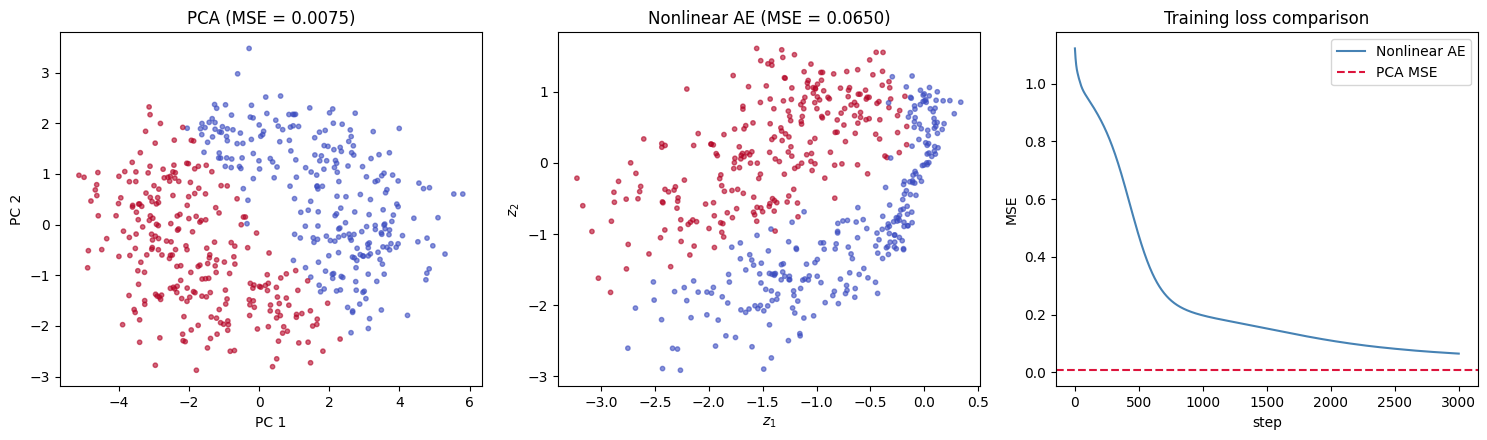

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].scatter(Z_pca[:, 0], Z_pca[:, 1], c=labels, cmap='coolwarm', s=10, alpha=0.6)
axes[0].set_title(f'PCA (MSE = {mse_pca:.4f})')
axes[0].set_xlabel('PC 1'); axes[0].set_ylabel('PC 2')

axes[1].scatter(Z_nl[:, 0], Z_nl[:, 1], c=labels, cmap='coolwarm', s=10, alpha=0.6)
axes[1].set_title(f'Nonlinear AE (MSE = {mse_nl:.4f})')
axes[1].set_xlabel('$z_1$'); axes[1].set_ylabel('$z_2$')

axes[2].plot(history_nl, color='steelblue', label='Nonlinear AE')
axes[2].axhline(mse_pca, color='crimson', ls='--', label=f'PCA MSE')
axes[2].set_xlabel('step'); axes[2].set_ylabel('MSE')
axes[2].set_title('Training loss comparison')
axes[2].legend()

plt.tight_layout()
plt.show()

### 4.3 Denoising Autoencoder

Corrupt the input with Gaussian noise and train to reconstruct the clean version.
This forces the encoder to learn robust features.

In [11]:
class DenoisingAutoencoder(NonlinearAutoencoder):
    """Nonlinear autoencoder trained with input corruption."""

    def fit(self, X, noise_std=0.5, lr=0.003, n_steps=3000, verbose=True):
        n, d = X.shape
        rng_noise = np.random.default_rng(SEED + 100)
        history = []
        for step in range(n_steps):
            # Corrupt input
            noise = rng_noise.normal(0, noise_std, size=X.shape)
            X_noisy = X + noise

            # Forward with noisy input, loss against clean input
            X_hat, Z = self.forward(X_noisy)
            loss = mse_loss(X, X_hat)  # reconstruct clean X
            history.append(loss)

            # Backprop (gradient w.r.t. clean X target)
            dX_hat = 2.0 * (X_hat - X) / (n * d)

            dW4 = self._A3.T @ dX_hat
            db4 = dX_hat.sum(axis=0)
            dA3 = dX_hat @ self.W4.T

            dH3 = dA3 * relu_deriv(self._H3)
            dW3 = Z.T @ dH3
            db3 = dH3.sum(axis=0)
            dZ = dH3 @ self.W3.T

            dW2 = self._A1.T @ dZ
            db2 = dZ.sum(axis=0)
            dA1 = dZ @ self.W2.T

            dH1 = dA1 * relu_deriv(self._H1)
            dW1 = X_noisy.T @ dH1  # note: use noisy input for encoder grad
            db1 = dH1.sum(axis=0)

            for param, grad in [(self.W1, dW1), (self.b1, db1),
                                (self.W2, dW2), (self.b2, db2),
                                (self.W3, dW3), (self.b3, db3),
                                (self.W4, dW4), (self.b4, db4)]:
                param -= lr * grad

            if verbose and (step + 1) % 1000 == 0:
                print(f'  step {step+1}/{n_steps}, loss = {loss:.6f}')
        return history


dae = DenoisingAutoencoder(n_features, d_hidden=16, d_latent=2, random_state=SEED + 1)
print('Training denoising autoencoder (noise_std=0.5)...')
history_dae = dae.fit(X_centered, noise_std=0.5, lr=0.003, n_steps=3000)

# Test: denoise a corrupted sample
X_test_noisy = X_centered + rng.normal(0, 0.5, size=X_centered.shape)
X_denoised, Z_dae = dae.forward(X_test_noisy)
mse_noisy = mse_loss(X_centered, X_test_noisy)
mse_denoised = mse_loss(X_centered, X_denoised)

print(f'\nMSE before denoising: {mse_noisy:.4f}')
print(f'MSE after denoising:  {mse_denoised:.4f}')
print(f'Denoising reduced error by {(1 - mse_denoised / mse_noisy) * 100:.1f}%')

Training denoising autoencoder (noise_std=0.5)...


  step 1000/3000, loss = 0.304251
  step 2000/3000, loss = 0.202914


  step 3000/3000, loss = 0.160514

MSE before denoising: 0.2532
MSE after denoising:  0.1599
Denoising reduced error by 36.8%


### 4.4 Variational Autoencoder (VAE)

The VAE encodes to a distribution $q(z|x) = \mathcal{N}(\mu, \sigma^2 I)$,
uses the reparameterization trick $z = \mu + \sigma \odot \varepsilon$,
and minimizes:

$$\mathcal{L}_{\text{VAE}} = \text{reconstruction MSE} + D_{\text{KL}}(q(z|x) \| p(z))$$

See [theory.md](theory.md) §6 for the full ELBO derivation.

In [12]:
class VAE:
    """Variational Autoencoder from scratch.
    
    Encoder: d -> h (ReLU) -> (mu, log_var) each of dim k
    Decoder: k -> h (ReLU) -> d (linear)
    """

    def __init__(self, d_input, d_hidden, d_latent, random_state=42):
        r = np.random.default_rng(random_state)
        self.d_latent = d_latent
        # Encoder shared layer
        self.W1 = he_init(d_input, d_hidden, r)
        self.b1 = np.zeros(d_hidden)
        # Encoder -> mu
        self.W_mu = xavier_init(d_hidden, d_latent, r)
        self.b_mu = np.zeros(d_latent)
        # Encoder -> log_var
        self.W_lv = xavier_init(d_hidden, d_latent, r)
        self.b_lv = np.zeros(d_latent)
        # Decoder
        self.W3 = he_init(d_latent, d_hidden, r)
        self.b3 = np.zeros(d_hidden)
        self.W4 = xavier_init(d_hidden, d_input, r)
        self.b4 = np.zeros(d_input)

    def encode(self, X):
        """Return mu, log_var."""
        self._H1 = X @ self.W1 + self.b1
        self._A1 = relu(self._H1)
        mu = self._A1 @ self.W_mu + self.b_mu
        log_var = self._A1 @ self.W_lv + self.b_lv
        return mu, log_var

    def reparameterize(self, mu, log_var, rng_sample):
        """z = mu + sigma * epsilon, epsilon ~ N(0, I)."""
        std = np.exp(0.5 * log_var)
        eps = rng_sample.normal(size=mu.shape)
        self._eps = eps
        self._std = std
        return mu + std * eps

    def decode(self, Z):
        self._H3 = Z @ self.W3 + self.b3
        self._A3 = relu(self._H3)
        X_hat = self._A3 @ self.W4 + self.b4
        return X_hat

    @staticmethod
    def kl_divergence(mu, log_var):
        """KL(q(z|x) || N(0,I)) = 0.5 * sum(mu^2 + var - log_var - 1)."""
        return 0.5 * np.sum(mu ** 2 + np.exp(log_var) - log_var - 1, axis=1).mean()

    def forward(self, X, rng_sample):
        self._X = X
        mu, log_var = self.encode(X)
        self._mu = mu
        self._log_var = log_var
        Z = self.reparameterize(mu, log_var, rng_sample)
        self._Z = Z
        X_hat = self.decode(Z)
        return X_hat, mu, log_var, Z

    def fit(self, X, lr=0.001, n_steps=5000, beta=1.0, verbose=True):
        """Train VAE. beta controls KL weight (beta=1 is standard ELBO)."""
        n, d = X.shape
        rng_train = np.random.default_rng(SEED + 200)
        history = {'loss': [], 'recon': [], 'kl': []}

        for step in range(n_steps):
            X_hat, mu, log_var, Z = self.forward(X, rng_train)

            # Losses
            recon_loss = mse_loss(X, X_hat)
            kl_loss = self.kl_divergence(mu, log_var)
            total_loss = recon_loss + beta * kl_loss
            history['loss'].append(total_loss)
            history['recon'].append(recon_loss)
            history['kl'].append(kl_loss)

            # Backprop through decoder
            dX_hat = 2.0 * (X_hat - X) / (n * d)

            dW4 = self._A3.T @ dX_hat
            db4 = dX_hat.sum(axis=0)
            dA3 = dX_hat @ self.W4.T

            dH3 = dA3 * relu_deriv(self._H3)
            dW3 = Z.T @ dH3
            db3 = dH3.sum(axis=0)
            dZ = dH3 @ self.W3.T

            # Backprop through reparameterization
            # z = mu + std * eps => dL/dmu = dL/dz, dL/dstd = dL/dz * eps
            # dL/dlog_var = dL/dstd * dstd/dlog_var = dL/dstd * 0.5*std
            dmu = dZ.copy()
            dstd = dZ * self._eps
            dlog_var = dstd * 0.5 * self._std

            # Add KL gradient
            # d(KL)/d(mu) = mu/n, d(KL)/d(log_var) = 0.5*(exp(log_var) - 1)/n
            dmu += beta * mu / n
            dlog_var += beta * 0.5 * (np.exp(log_var) - 1) / n

            # Encoder mu/log_var layer gradients
            dW_mu = self._A1.T @ dmu
            db_mu = dmu.sum(axis=0)
            dW_lv = self._A1.T @ dlog_var
            db_lv = dlog_var.sum(axis=0)

            # Back to shared encoder layer
            dA1 = dmu @ self.W_mu.T + dlog_var @ self.W_lv.T
            dH1 = dA1 * relu_deriv(self._H1)
            dW1 = X.T @ dH1
            db1 = dH1.sum(axis=0)

            # Gradient clipping for stability
            max_norm = 5.0
            for grad in [dW1, db1, dW_mu, db_mu, dW_lv, db_lv,
                         dW3, db3, dW4, db4]:
                norm = np.linalg.norm(grad)
                if norm > max_norm:
                    grad *= max_norm / norm

            # Update
            for param, grad in [(self.W1, dW1), (self.b1, db1),
                                (self.W_mu, dW_mu), (self.b_mu, db_mu),
                                (self.W_lv, dW_lv), (self.b_lv, db_lv),
                                (self.W3, dW3), (self.b3, db3),
                                (self.W4, dW4), (self.b4, db4)]:
                param -= lr * grad

            if verbose and (step + 1) % 1000 == 0:
                print(f'  step {step+1}/{n_steps}, loss = {total_loss:.4f} '
                      f'(recon = {recon_loss:.4f}, KL = {kl_loss:.4f})')

        return history

In [13]:
vae = VAE(n_features, d_hidden=32, d_latent=2, random_state=SEED)
print('Training VAE (8 -> 32 -> 2 -> 32 -> 8)...')
history_vae = vae.fit(X_centered, lr=0.001, n_steps=5000, beta=0.1)

rng_eval = np.random.default_rng(999)
X_hat_vae, mu_vae, lv_vae, Z_vae = vae.forward(X_centered, rng_eval)
mse_vae = mse_loss(X_centered, X_hat_vae)
print(f'\nVAE reconstruction MSE: {mse_vae:.6f}')

Training VAE (8 -> 32 -> 2 -> 32 -> 8)...


  step 1000/5000, loss = 0.7179 (recon = 0.5643, KL = 1.5358)


  step 2000/5000, loss = 0.5182 (recon = 0.3380, KL = 1.8017)


  step 3000/5000, loss = 0.4305 (recon = 0.2485, KL = 1.8203)


  step 4000/5000, loss = 0.4134 (recon = 0.2254, KL = 1.8796)


  step 5000/5000, loss = 0.3880 (recon = 0.1949, KL = 1.9312)

VAE reconstruction MSE: 0.180429


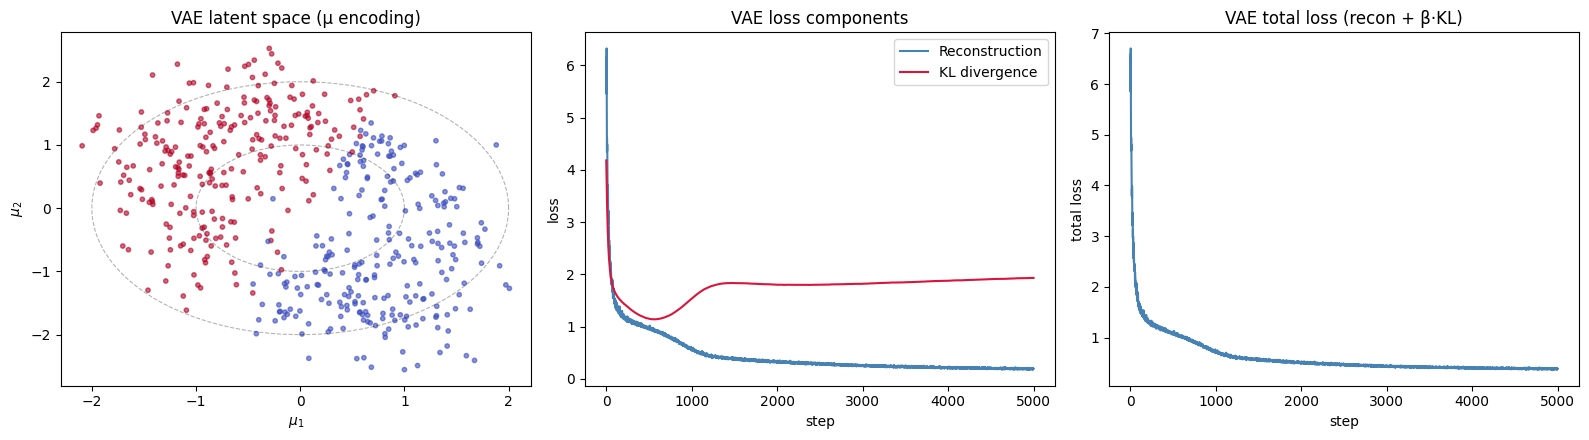

In [14]:
# Latent space visualization: 2D latent colored by class
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# VAE mean encoding (deterministic)
axes[0].scatter(mu_vae[:, 0], mu_vae[:, 1], c=labels, cmap='coolwarm', s=10, alpha=0.6)
axes[0].set_title('VAE latent space (μ encoding)')
axes[0].set_xlabel('$\\mu_1$'); axes[0].set_ylabel('$\\mu_2$')

# Overlay unit Gaussian contour to show KL regularization effect
theta_circle = np.linspace(0, 2 * np.pi, 100)
for r in [1, 2]:
    axes[0].plot(r * np.cos(theta_circle), r * np.sin(theta_circle),
                 'k--', alpha=0.3, lw=0.8)

# Training curves
axes[1].plot(history_vae['recon'], label='Reconstruction', color='steelblue')
axes[1].plot(history_vae['kl'], label='KL divergence', color='crimson')
axes[1].set_xlabel('step'); axes[1].set_ylabel('loss')
axes[1].set_title('VAE loss components')
axes[1].legend()

axes[2].plot(history_vae['loss'], color='steelblue')
axes[2].set_xlabel('step'); axes[2].set_ylabel('total loss')
axes[2].set_title('VAE total loss (recon + β·KL)')

plt.tight_layout()
plt.show()

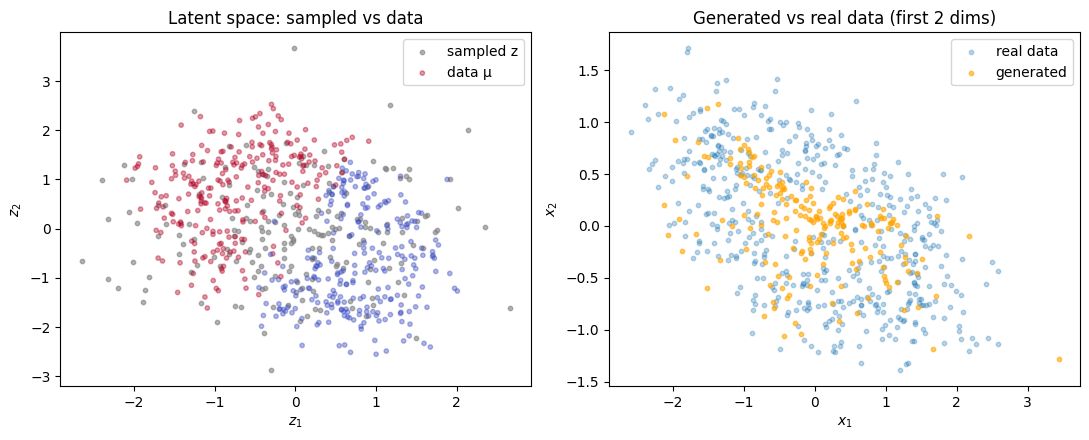

In [15]:
# Generate new samples from the VAE by sampling z ~ N(0, I)
n_gen = 200
rng_gen = np.random.default_rng(77)
Z_gen = rng_gen.normal(size=(n_gen, 2))
X_gen = vae.decode(Z_gen)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(Z_gen[:, 0], Z_gen[:, 1], s=10, alpha=0.6, color='gray', label='sampled z')
axes[0].scatter(mu_vae[:, 0], mu_vae[:, 1], c=labels, cmap='coolwarm', s=10, alpha=0.4, label='data μ')
axes[0].set_title('Latent space: sampled vs data')
axes[0].set_xlabel('$z_1$'); axes[0].set_ylabel('$z_2$')
axes[0].legend()

axes[1].scatter(X_centered[:, 0], X_centered[:, 1], s=10, alpha=0.3, label='real data')
axes[1].scatter(X_gen[:, 0], X_gen[:, 1], s=10, alpha=0.6, color='orange', label='generated')
axes[1].set_title('Generated vs real data (first 2 dims)')
axes[1].set_xlabel('$x_1$'); axes[1].set_ylabel('$x_2$')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Library Comparison

Compare our scratch VAE with a PyTorch implementation.

In [16]:
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
except ModuleNotFoundError:
    print('PyTorch not installed; skipping comparison.')
else:
    torch.manual_seed(SEED)

    class TorchVAE(nn.Module):
        def __init__(self, d_input, d_hidden, d_latent):
            super().__init__()
            self.enc_fc = nn.Linear(d_input, d_hidden)
            self.fc_mu = nn.Linear(d_hidden, d_latent)
            self.fc_lv = nn.Linear(d_hidden, d_latent)
            self.dec_fc = nn.Linear(d_latent, d_hidden)
            self.dec_out = nn.Linear(d_hidden, d_input)

        def encode(self, x):
            h = torch.relu(self.enc_fc(x))
            return self.fc_mu(h), self.fc_lv(h)

        def reparameterize(self, mu, log_var):
            std = torch.exp(0.5 * log_var)
            eps = torch.randn_like(std)
            return mu + std * eps

        def decode(self, z):
            h = torch.relu(self.dec_fc(z))
            return self.dec_out(h)

        def forward(self, x):
            mu, log_var = self.encode(x)
            z = self.reparameterize(mu, log_var)
            return self.decode(z), mu, log_var

    def vae_loss_torch(x, x_hat, mu, log_var, beta=0.1):
        recon = nn.functional.mse_loss(x_hat, x)
        kl = -0.5 * torch.mean(torch.sum(1 + log_var - mu.pow(2) - log_var.exp(), dim=1))
        return recon + beta * kl, recon, kl

    X_t = torch.tensor(X_centered, dtype=torch.float32)
    model_pt = TorchVAE(n_features, 32, 2)
    optimizer = optim.Adam(model_pt.parameters(), lr=0.001)

    pt_losses = []
    for step in range(5000):
        optimizer.zero_grad()
        x_hat, mu_pt, lv_pt = model_pt(X_t)
        loss, recon, kl = vae_loss_torch(X_t, x_hat, mu_pt, lv_pt)
        loss.backward()
        optimizer.step()
        pt_losses.append(loss.item())

    with torch.no_grad():
        x_hat_pt, mu_pt_final, _ = model_pt(X_t)
        mse_pt = nn.functional.mse_loss(x_hat_pt, X_t).item()
        mu_np = mu_pt_final.numpy()

    print(f'PyTorch VAE reconstruction MSE: {mse_pt:.6f}')
    print(f'Scratch  VAE reconstruction MSE: {mse_vae:.6f}')

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    axes[0].scatter(mu_np[:, 0], mu_np[:, 1], c=labels, cmap='coolwarm', s=10, alpha=0.6)
    axes[0].set_title(f'PyTorch VAE latent (MSE = {mse_pt:.4f})')
    axes[0].set_xlabel('$\\mu_1$'); axes[0].set_ylabel('$\\mu_2$')

    axes[1].scatter(mu_vae[:, 0], mu_vae[:, 1], c=labels, cmap='coolwarm', s=10, alpha=0.6)
    axes[1].set_title(f'Scratch VAE latent (MSE = {mse_vae:.4f})')
    axes[1].set_xlabel('$\\mu_1$'); axes[1].set_ylabel('$\\mu_2$')

    plt.tight_layout()
    plt.show()
    print('Both VAEs learn a structured latent space. ✓')

PyTorch not installed; skipping comparison.


## 6. Experiments and Failures — VERIFY

### 6.1 Bottleneck too small vs too large

k = 1: MSE = 0.236012


k = 2: MSE = 0.110126


k = 4: MSE = 0.036961


k = 8: MSE = 0.053847


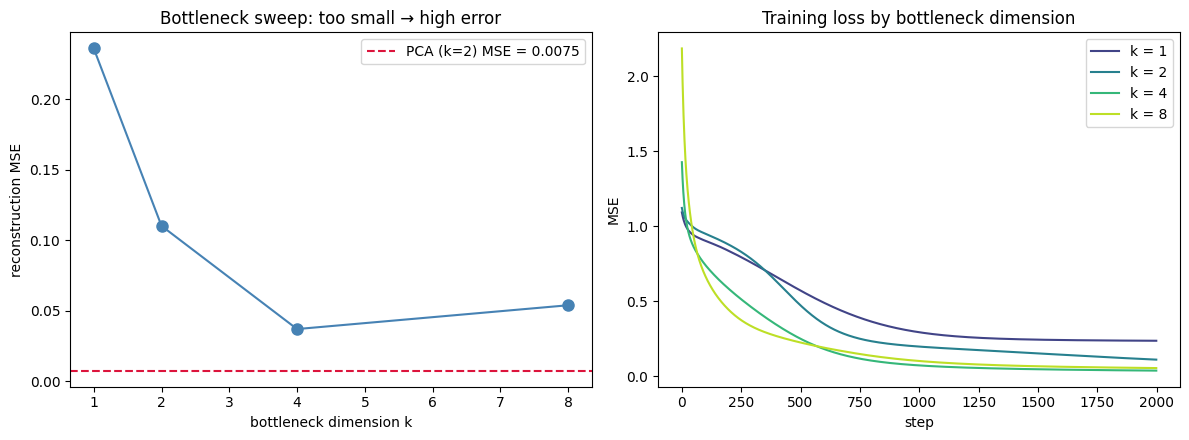


k=1 (too small): MSE = 0.2360 — loses structure
k=2 (just right): MSE = 0.1101 — matches intrinsic dim
k=8 (= input dim): MSE = 0.0538 — near-identity, no compression


In [17]:
# Bottleneck dimension sweep
bottleneck_dims = [1, 2, 4, 8]
results = []

for k in bottleneck_dims:
    ae_k = NonlinearAutoencoder(n_features, d_hidden=16, d_latent=k, random_state=SEED)
    hist_k = ae_k.fit(X_centered, lr=0.003, n_steps=2000, verbose=False)
    X_hat_k, _ = ae_k.forward(X_centered)
    mse_k = mse_loss(X_centered, X_hat_k)
    results.append((k, mse_k, hist_k))
    print(f'k = {k}: MSE = {mse_k:.6f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# MSE vs bottleneck dimension
ks = [r[0] for r in results]
mses = [r[1] for r in results]
axes[0].plot(ks, mses, 'o-', color='steelblue', markersize=8)
axes[0].axhline(mse_pca, color='crimson', ls='--', label=f'PCA (k=2) MSE = {mse_pca:.4f}')
axes[0].set_xlabel('bottleneck dimension k')
axes[0].set_ylabel('reconstruction MSE')
axes[0].set_title('Bottleneck sweep: too small → high error')
axes[0].legend()

# Training curves
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(bottleneck_dims)))
for (k, mse_k, hist_k), c in zip(results, colors):
    axes[1].plot(hist_k, color=c, label=f'k = {k}')
axes[1].set_xlabel('step')
axes[1].set_ylabel('MSE')
axes[1].set_title('Training loss by bottleneck dimension')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'\nk=1 (too small): MSE = {results[0][1]:.4f} — loses structure')
print(f'k=2 (just right): MSE = {results[1][1]:.4f} — matches intrinsic dim')
print(f'k=8 (= input dim): MSE = {results[3][1]:.4f} — near-identity, no compression')

In [18]:
# Verify shape and reconstruction quality checks
X_hat_check, Z_check = nl_ae.forward(X_centered)

assert X_hat_check.shape == X_centered.shape, f'Bad reconstruction shape: {X_hat_check.shape}'
assert Z_check.shape == (n_samples, 2), f'Bad latent shape: {Z_check.shape}'
assert mse_loss(X_centered, X_hat_check) < 0.1, 'Reconstruction error too high'
print(f'Reconstruction shape: {X_hat_check.shape} ✓')
print(f'Latent shape: {Z_check.shape} ✓')
print(f'MSE < 0.1: {mse_loss(X_centered, X_hat_check):.6f} ✓')

Reconstruction shape: (500, 8) ✓
Latent shape: (500, 2) ✓
MSE < 0.1: 0.065014 ✓


### 6.2 VAE with and without KL regularization

VAE without KL (beta=0)...


VAE with KL (beta=0.1)...


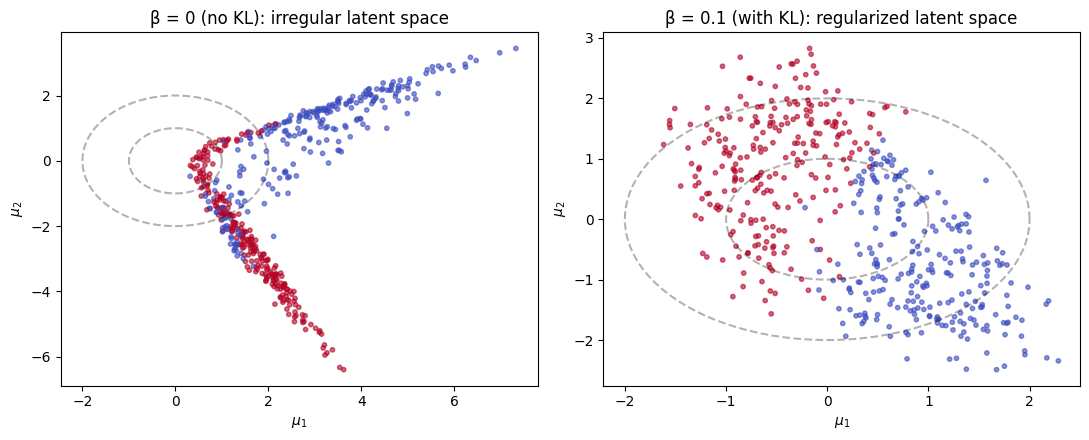

Without KL: latent space has gaps/holes — sampling z ~ N(0,I) may decode poorly.
With KL: latent space is more regular — supports generation via sampling.


In [19]:
# Train VAE without KL (beta=0) vs with KL (beta=0.1)
vae_no_kl = VAE(n_features, d_hidden=32, d_latent=2, random_state=SEED)
print('VAE without KL (beta=0)...')
hist_no_kl = vae_no_kl.fit(X_centered, lr=0.001, n_steps=3000, beta=0.0, verbose=False)

vae_with_kl = VAE(n_features, d_hidden=32, d_latent=2, random_state=SEED)
print('VAE with KL (beta=0.1)...')
hist_with_kl = vae_with_kl.fit(X_centered, lr=0.001, n_steps=3000, beta=0.1, verbose=False)

rng_compare = np.random.default_rng(123)
_, mu_no_kl, _, _ = vae_no_kl.forward(X_centered, rng_compare)
rng_compare2 = np.random.default_rng(123)
_, mu_with_kl, _, _ = vae_with_kl.forward(X_centered, rng_compare2)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].scatter(mu_no_kl[:, 0], mu_no_kl[:, 1], c=labels, cmap='coolwarm', s=10, alpha=0.6)
axes[0].set_title('β = 0 (no KL): irregular latent space')
axes[0].set_xlabel('$\\mu_1$'); axes[0].set_ylabel('$\\mu_2$')
for r in [1, 2]:
    axes[0].plot(r * np.cos(theta_circle), r * np.sin(theta_circle), 'k--', alpha=0.3)

axes[1].scatter(mu_with_kl[:, 0], mu_with_kl[:, 1], c=labels, cmap='coolwarm', s=10, alpha=0.6)
axes[1].set_title('β = 0.1 (with KL): regularized latent space')
axes[1].set_xlabel('$\\mu_1$'); axes[1].set_ylabel('$\\mu_2$')
for r in [1, 2]:
    axes[1].plot(r * np.cos(theta_circle), r * np.sin(theta_circle), 'k--', alpha=0.3)

plt.tight_layout()
plt.show()
print('Without KL: latent space has gaps/holes — sampling z ~ N(0,I) may decode poorly.')
print('With KL: latent space is more regular — supports generation via sampling.')

## 7. Connections

- **Theory:** [theory.md](theory.md) — ELBO derivation, reparameterization, failure cases
- **PCA:** [topic 10](../10_pca/README.md) — linear AE recovers PCA subspace
- **Neural Networks:** [topic 13](../13_neural_networks/README.md) — encoder/decoder are MLPs
- **Dimensionality Reduction:** [topic 12](../12_dimensionality_reduction/README.md) — autoencoder as nonlinear alternative
- **Information Theory:** KL divergence regularizes the VAE latent space

## Takeaway

- A **linear autoencoder** with bottleneck $k$ recovers the same subspace as PCA. This is the simplest case.
- A **nonlinear autoencoder** (ReLU hidden layers) can capture curved manifolds that PCA misses.
- A **denoising autoencoder** learns robust features by reconstructing clean data from corrupted input.
- A **VAE** adds distributional structure to the latent space via the reparameterization trick and KL divergence, enabling generation.
- **Bottleneck dimension** is critical: too small loses information, too large allows memorization.
- **KL regularization** makes the VAE latent space smooth and well-structured for sampling.